<a href="https://colab.research.google.com/github/mthudangn/llm-therapy-fidelity/blob/experiment/notebooks/thesis_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# I. Introduction

## 1.1. Library and Dataset Import

In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from google.colab import files

In [20]:
LOCAL_PATH = "/content/AnnoMI-full.csv"

def load_data():
    global _df_cache

    # 1. Memory cache
    if '_df_cache' in globals() and _df_cache is not None:
        print("---> Load data from in-memory cache")
        return _df_cache

    # 2. Local storage
    if os.path.exists(LOCAL_PATH):
        print("---> Load data from local")
        _df_cache = pd.read_csv(LOCAL_PATH)
        return _df_cache

    # 3. GitHub
    try:
        print("---> Load data from GitHub")
        github_url = "https://raw.githubusercontent.com/mthudangn/llm-therapy-fidelity/experiment/data/AnnoMI-full.csv"
        _df_cache = pd.read_csv(github_url)
        _df_cache.to_csv(LOCAL_PATH, index=False)
        return _df_cache
    except Exception as e:
        print("GitHub access expired - ", e)

    # 4. Google Drive
    drive_url = "https://drive.google.com/uc?id=1J6v0T4kFXGY_OEZXo-_0SYBLhwLy8qtl"
    try:
        print("---> Load data from Google Drive")
        _df_cache = pd.read_csv(drive_url)
        _df_cache.to_csv(LOCAL_PATH, index=False)
        return _df_cache
    except Exception:
        pass

    # 5. Manual download & upload
    print("⚠️ Please download file:\n" + drive_url + "\nand upload AnnoMI-full.csv manually")
    uploaded = files.upload()

    filename = list(uploaded.keys())[0]
    _df_cache = pd.read_csv(filename)
    _df_cache.to_csv(LOCAL_PATH, index=False)

    return _df_cache

df = load_data()

---> Load data from in-memory cache


In [21]:
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (13551, 18)


,mi_quality,transcript_id,video_title,video_url,topic,utterance_id,interlocutor,timestamp,utterance_text,annotator_id,therapist_input_exists,therapist_input_subtype,reflection_exists,reflection_subtype,question_exists,question_subtype,main_therapist_behaviour,client_talk_type
0,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,0,therapist,00:00:13,Thanks for filling it out. We give this form t...,3,False,NaN,False,NaN,True,open,question,NaN
1,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,1,client,00:00:24,Sure.,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neutral
2,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,2,therapist,00:00:25,"So, let's see. It looks that you put-- You dri...",3,True,information,False,NaN,False,NaN,therapist_input,NaN
3,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,3,client,00:00:34,Mm-hmm.,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neutral
4,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,4,therapist,00:00:34,-and you usually have three to four drinks whe...,3,True,information,False,NaN,False,NaN,therapist_input,NaN


The original dataset contains multiple annotations per utterance. These annotations are aggregated into a single consensus label using majority voting, resulting in an utterance-level dataset used for EDA.

In [22]:
# Build utterance-level consensus dataframe
# Purpose:
# - Collapse repeated annotations for the same utterance
# - Keep one final row per (transcript_id, utterance_id)
# - Keep only columns needed for EDA & modelling

def mode_or_nan(series):
    s = series.dropna().astype(str).str.strip()
    s = s[s != ""]
    s = s[s.str.lower() != "nan"]
    if len(s) == 0:
        return np.nan
    return s.mode().iloc[0]

keep_cols = [
    "transcript_id",
    "utterance_id",
    "mi_quality",
    "interlocutor",
    "utterance_text",
    "main_therapist_behaviour",
    "client_talk_type",
]

use_cols = [c for c in keep_cols if c in df.columns]

df_small = df[use_cols].copy()


# Majority vote of annotators
df_consensus = (
    df_small
    .groupby(["transcript_id", "utterance_id"], as_index=False)
    .agg({
        "mi_quality": mode_or_nan,
        "interlocutor": mode_or_nan,
        "utterance_text": mode_or_nan,
        "main_therapist_behaviour": mode_or_nan,
        "client_talk_type": mode_or_nan,
    })
    .sort_values(["transcript_id", "utterance_id"])
    .reset_index(drop=True)
)

for col in ["mi_quality", "interlocutor", "main_therapist_behaviour", "client_talk_type"]:
    if col in df_consensus.columns:
        df_consensus[col] = df_consensus[col].astype(str).str.strip().str.lower()
        df_consensus.loc[df_consensus[col] == "nan", col] = np.nan

print("Raw shape:", df.shape)
print("Consensus shape:", df_consensus.shape)
print(
    "Remaining duplicate utterances:",
    df_consensus.duplicated(subset=["transcript_id", "utterance_id"]).sum()
)

df_consensus.head()

Raw shape: (13551, 18)
Consensus shape: (9699, 7)
Remaining duplicate utterances: 0


,transcript_id,utterance_id,mi_quality,interlocutor,utterance_text,main_therapist_behaviour,client_talk_type
0,0,0,high,therapist,Thanks for filling it out. We give this form t...,question,NaN
1,0,1,high,client,Sure.,NaN,neutral
2,0,2,high,therapist,"So, let's see. It looks that you put-- You dri...",therapist_input,NaN
3,0,3,high,client,Mm-hmm.,NaN,neutral
4,0,4,high,therapist,-and you usually have three to four drinks whe...,therapist_input,NaN


## 1.2. Data Inspection

In [71]:
print("Columns:")
print(df_consensus.columns.tolist())
print("\nData types:")
print(df_consensus.dtypes)
print("\nMissing values:")
print(df_consensus.isna().sum())

Columns:
['transcript_id', 'utterance_id', 'mi_quality', 'interlocutor', 'utterance_text', 'main_therapist_behaviour', 'client_talk_type']

Data types:
transcript_id                int64
utterance_id                 int64
mi_quality                  object
interlocutor                object
utterance_text              object
main_therapist_behaviour    object
client_talk_type            object
dtype: object

Missing values:
transcript_id                  0
utterance_id                   0
mi_quality                     0
interlocutor                   0
utterance_text                 0
main_therapist_behaviour    4817
client_talk_type            4882
dtype: int64


In [24]:
display(df.sample(min(5, len(df)), random_state=42))

,mi_quality,transcript_id,video_title,video_url,topic,utterance_id,interlocutor,timestamp,utterance_text,annotator_id,therapist_input_exists,therapist_input_subtype,reflection_exists,reflection_subtype,question_exists,question_subtype,main_therapist_behaviour,client_talk_type
811,high,7,Doctor Uses Motivational Interviewing to Discu...,https://www.youtube.com/watch?v=_HpKn29oCD0,reducing alcohol consumption,35,client,00:03:38,"Uh, uh I would say a little over that.",3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neutral
13474,low,131,Stop smoking - initial consultation,https://www.youtube.com/watch?v=pL3zIl2hS-o,smoking cessation,14,therapist,00:01:02,How much does it actually cost you a week?,9,False,NaN,False,NaN,True,closed,question,NaN
12503,low,27,How NOT to do Motivational Interviewing: A con...,https://www.youtube.com/watch?v=kN7T-cmb_l0,asthma management,12,therapist,00:01:17,"-and you are very concerned about your health,...",7,False,NaN,False,NaN,False,NaN,other,NaN
8457,high,88,MI-Change Plan,https://www.youtube.com/watch?v=DYQ6KVWv5xU,compliance with rules,31,therapist,00:02:41,When would be a great day for you to start this?,9,True,negotiation,False,NaN,True,closed,question,NaN
6415,high,62,EPE Role Play,https://www.youtube.com/watch?v=31r4rCwoa_o,completion of community service,40,client,00:02:52,I think that's it. I think I was just worried ...,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,change


### Value counts for important categorical columns, including subtype columns

In [25]:
for col in [
    "interlocutor",
    "main_therapist_behaviour",
    "client_talk_type",
    "mi_quality",
    "question_exists",
    "question_subtype",
    "reflection_exists",
    "reflection_subtype",
    "therapist_input_subtype"
]:
    if col in df.columns:
        print(f"\n===== {col} =====")
        print(df[col].value_counts(dropna=False))



===== interlocutor =====
interlocutor
therapist    6826
client       6725
Name: count, dtype: int64

===== main_therapist_behaviour =====
main_therapist_behaviour
NaN                6725
other              2143
question           1954
reflection         1717
therapist_input    1012
Name: count, dtype: int64

===== client_talk_type =====
client_talk_type
NaN        6826
neutral    4217
change     1668
sustain     840
Name: count, dtype: int64

===== mi_quality =====
mi_quality
high    12286
low      1265
Name: count, dtype: int64

===== question_exists =====
question_exists
NaN      6725
False    4513
True     2313
Name: count, dtype: int64

===== question_subtype =====
question_subtype
NaN       11238
open       1340
closed      973
Name: count, dtype: int64

===== reflection_exists =====
reflection_exists
NaN      6725
False    4805
True     2021
Name: count, dtype: int64

===== reflection_subtype =====
reflection_subtype
NaN        11530
simple      1070
complex      951
Name: count

### Therapist and Client Data Split

Each utterance is assigned a single dominant behaviour label, while additional annotation fields capture the presence of multiple behavioural elements, enabling analysis of intervention fidelity beyond simple classification.

In [26]:
therapist_df = df_consensus[df_consensus["interlocutor"] == "therapist"].copy()
client_df = df_consensus[df_consensus["interlocutor"] == "client"].copy()

print("---> Therapist rows shape:", therapist_df.shape)
print("---> Client rows shape   :", client_df.shape)

print("\n---> Therapist behaviour labels:")
print(therapist_df["main_therapist_behaviour"].value_counts(dropna=False))

print("\n---> Client talk labels:")
print(client_df["client_talk_type"].value_counts(dropna=False))

---> Therapist rows shape: (4882, 7)
---> Client rows shape   : (4817, 7)

---> Therapist behaviour labels:
main_therapist_behaviour
other              1587
question           1386
reflection         1297
therapist_input     612
Name: count, dtype: int64

---> Client talk labels:
client_talk_type
neutral    3101
change     1177
sustain     539
Name: count, dtype: int64


Behavioural complexity was quantified by counting the number of behavioural indicators (i.e., question, reflection, and therapist input) present in each therapist utterance.

The distribution indicates that the majority of utterances contain a single behavioural element (n = 3,876), consistent with the dataset’s single-label annotation scheme. A substantial proportion of utterances contain no behavioural signals (n = 2,143), corresponding to non-therapeutic or filler dialogue. Additionally, a smaller subset of utterances exhibits multiple behavioural elements (n = 747 for two behaviours and n = 60 for three behaviours), indicating that therapist responses may simultaneously fulfil multiple communicative functions.

These results demonstrate that, although each utterance is assigned a single dominant behaviour label, the underlying conversational structure is inherently multi-behavioural. This distinction is important for modelling intervention fidelity beyond simple classification.

Accordingly, intervention fidelity assessment should account for the presence of multiple behavioural signals rather than relying solely on single-label classification.

---

# II. Data Preprocessing

## 2.1. Text Cleaning & Annotation Standardization

In [27]:
# Minimal cleaning only
# - Keep semantic content
# - Do NOT lowercase or remove punctuation for transformer models
therapist_df["utterance_text_raw"] = therapist_df["utterance_text"].copy()
therapist_df["utterance_text"] = (
    therapist_df["utterance_text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
# Remove empty utterances after cleaning
therapist_df = therapist_df[therapist_df["utterance_text"] != ""].copy()

client_df["utterance_text_raw"] = client_df["utterance_text"].copy()
client_df["utterance_text"] = (
    client_df["utterance_text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
client_df = client_df[client_df["utterance_text"] != ""].copy()

print("After text cleaning:\n")
print("- Therapist data:", therapist_df.shape)
print("- Client data:", client_df.shape)

# Main label normalisation
therapist_df["main_therapist_behaviour"] = (
    therapist_df["main_therapist_behaviour"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({"nan": "n/a", "": "n/a"})
)

# Useful for fidelity/session aggregation
therapist_df["mi_quality"] = therapist_df["mi_quality"].astype(str).str.strip().str.lower()

After text cleaning:

- Therapist data: (4882, 8)
- Client data: (4817, 8)


# III. Exploratory Data Analysis (EDA)

## 3.1. Class distribution plot

Therapist behaviour distribution by MI quality (%)


mi_quality,high,low
main_therapist_behaviour,,
other,32.94,28.12
question,28.03,31.97
reflection,28.51,7.03
therapist_input,10.52,32.88


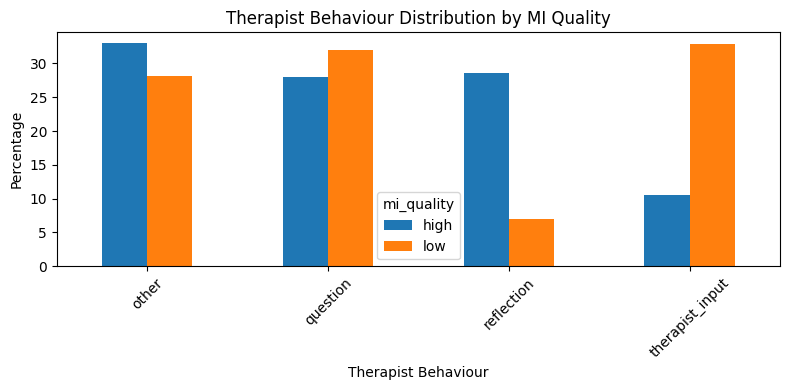

In [30]:
therapist_eda = therapist_df.dropna(subset=["main_therapist_behaviour", "mi_quality"]).copy()

therapist_counts = (
    therapist_eda
    .groupby(["mi_quality", "main_therapist_behaviour"])
    .size()
    .reset_index(name="n")
)

therapist_counts["ratio"] = therapist_counts.groupby("mi_quality")["n"].transform(lambda s: s / s.sum())

therapist_pivot = therapist_counts.pivot(
    index="main_therapist_behaviour",
    columns="mi_quality",
    values="ratio"
).fillna(0)

print("Therapist behaviour distribution by MI quality (%)")
display((therapist_pivot * 100).round(2))

(therapist_pivot * 100).plot(kind="bar", figsize=(8, 4))
plt.title("Therapist Behaviour Distribution by MI Quality")
plt.xlabel("Therapist Behaviour")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Inspect transcript-level MI quality

In [33]:
if "mi_quality" in therapist_df.columns:
    print(therapist_df[["transcript_id", "mi_quality"]].drop_duplicates()["mi_quality"].value_counts(dropna=False))

mi_quality
high    110
low      23
Name: count, dtype: int64


Client talk distribution by MI quality (%)


mi_quality,high,low
client_talk_type,,
change,25.13,17.18
neutral,64.05,67.78
sustain,10.82,15.04


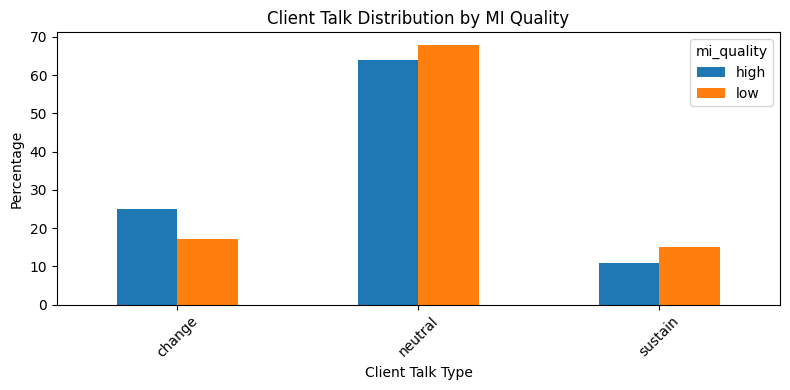

In [34]:
client_eda = client_df.dropna(subset=["client_talk_type", "mi_quality"]).copy()

client_counts = (
    client_eda
    .groupby(["mi_quality", "client_talk_type"])
    .size()
    .reset_index(name="n")
)

client_counts["ratio"] = client_counts.groupby("mi_quality")["n"].transform(lambda s: s / s.sum())

client_pivot = client_counts.pivot(
    index="client_talk_type",
    columns="mi_quality",
    values="ratio"
).fillna(0)

print("Client talk distribution by MI quality (%)")
display((client_pivot * 100).round(2))

(client_pivot * 100).plot(kind="bar", figsize=(8, 4))
plt.title("Client Talk Distribution by MI Quality")
plt.xlabel("Client Talk Type")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
print("=== Key Pattern Check ===")

if "reflection" in therapist_pivot.index:
    print("Reflection:", (therapist_pivot.loc["reflection"] * 100).round(2).to_dict())

if "therapist_input" in therapist_pivot.index:
    print("Therapist input:", (therapist_pivot.loc["therapist_input"] * 100).round(2).to_dict())

if "question" in therapist_pivot.index:
    print("Question:", (therapist_pivot.loc["question"] * 100).round(2).to_dict())

if "change" in client_pivot.index:
    print("Change talk:", (client_pivot.loc["change"] * 100).round(2).to_dict())

if "sustain" in client_pivot.index:
    print("Sustain talk:", (client_pivot.loc["sustain"] * 100).round(2).to_dict())

=== Key Pattern Check ===
Reflection: {'high': 28.51, 'low': 7.03}
Therapist input: {'high': 10.52, 'low': 32.88}
Question: {'high': 28.03, 'low': 31.97}
Change talk: {'high': 25.13, 'low': 17.18}
Sustain talk: {'high': 10.82, 'low': 15.04}


High-quality MI sessions are characterised by a higher proportion of reflective statements and a lower proportion of directive input, whereas low-quality sessions exhibit the opposite pattern. High MI therapist tends to listen and reflect, while low MI therapist tends to tell and direct.

- Reflection ↑ in high MI because it encourages client's change talk  
- Input ↑ in low MI because it triggers client's sustain talk (resistance)

### Examples from each therapist behaviour class





In [36]:
labels = therapist_df["main_therapist_behaviour"].dropna().unique().tolist()

for label in sorted(labels):
    print(f"\n===== Examples: {label} =====")
    sample_rows = therapist_df[therapist_df["main_therapist_behaviour"] == label][["utterance_text"]].head(5)
    for i, txt in enumerate(sample_rows["utterance_text"], 1):
        print(f"{i}. {txt}")


===== Examples: other =====
1. Great. So, let's see how well you're doing with these new meds.
2. Okay.
3. Okay. Good.
4. Hi, Emily.
5. It's been a while.

===== Examples: question =====
1. Thanks for filling it out. We give this form to everyone once a year regardless of why they come in. It helps us provide better care. Is it okay if I take a look at what you put down?
2. Uh, what else can you tell me about your drinking.
3. Okay. So, can I share with you some information on alcohol use?
4. Yeah, you're surprised to hear that?
5. Well, how do you think your drinking relates to the depression you've experienced?

===== Examples: reflection =====
1. Right. By the way, binge drinking is defined for women as having more than, uh, three drinks and there are about five drinks in a bottle. So, you enjoy drinking wine because it helps make things, uh, a little bit more interesting when you're feeling down but at the same time you don't like drinking when you have more than you want it to an

---

# II. Data Preprocessing

Prepare a clean therapist-utterance dataset for modelling.

In [37]:
prep_df = therapist_df[
    [
        "transcript_id",
        "utterance_text",
        "main_therapist_behaviour",
        "mi_quality"
    ]
].copy()

prep_df = prep_df.rename(columns={
    "utterance_text": "text",
    "main_therapist_behaviour": "label"
})

print("prep_df shape:", prep_df.shape)
prep_df.head()

prep_df shape: (4882, 4)


,transcript_id,text,label,mi_quality
0,0,Thanks for filling it out. We give this form t...,question,high
2,0,"So, let's see. It looks that you put-- You dri...",therapist_input,high
4,0,-and you usually have three to four drinks whe...,therapist_input,high
6,0,Okay. That's at least 12 drinks a week.,therapist_input,high
8,0,"Okay. Just so you know, my role, um, when we t...",therapist_input,high


## Remove missing and duplicate rows

In [38]:
prep_df = prep_df.dropna(subset=["text", "label"]).copy()
prep_df["text"] = prep_df["text"].astype(str).str.strip()
prep_df = prep_df[prep_df["text"] != ""].copy()

print("prep_df shape after cleaning:", prep_df.shape)

prep_df shape after cleaning: (4882, 4)


## Normalize text

In [39]:
import re

def clean_text(text):
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    return text

prep_df["text"] = prep_df["text"].apply(clean_text)

prep_df.head()

,transcript_id,text,label,mi_quality
0,0,Thanks for filling it out. We give this form t...,question,high
2,0,"So, let's see. It looks that you put-- You dri...",therapist_input,high
4,0,-and you usually have three to four drinks whe...,therapist_input,high
6,0,Okay. That's at least 12 drinks a week.,therapist_input,high
8,0,"Okay. Just so you know, my role, um, when we t...",therapist_input,high


In [40]:
# Inspect label distribution after cleaning
label_counts = prep_df["label"].value_counts()
label_counts

,count
label,
other,1587
question,1386
reflection,1297
therapist_input,612


## Encode labels

In [41]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
prep_df["label_id"] = label_encoder.fit_transform(prep_df["label"])

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(label_mapping)

{'other': np.int64(0), 'question': np.int64(1), 'reflection': np.int64(2), 'therapist_input': np.int64(3)}


## Stratified train/validation/test split

In [42]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    prep_df,
    test_size=0.30,
    random_state=42,
    stratify=prep_df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train shape:", train_df.shape)
print("Val shape  :", val_df.shape)
print("Test shape :", test_df.shape)

Train shape: (3417, 5)
Val shape  : (732, 5)
Test shape : (733, 5)


In [43]:
# Sanity check label balance across splits

print("Train label distribution:")
print(train_df["label"].value_counts(normalize=True).round(3))

print("\nValidation label distribution:")
print(val_df["label"].value_counts(normalize=True).round(3))

print("\nTest label distribution:")
print(test_df["label"].value_counts(normalize=True).round(3))

Train label distribution:
label
other              0.325
question           0.284
reflection         0.266
therapist_input    0.125
Name: proportion, dtype: float64

Validation label distribution:
label
other              0.325
question           0.284
reflection         0.265
therapist_input    0.126
Name: proportion, dtype: float64

Test label distribution:
label
other              0.325
question           0.284
reflection         0.266
therapist_input    0.126
Name: proportion, dtype: float64


In [44]:
X_train = train_df["text"].tolist()
y_train = train_df["label_id"].tolist()

X_val = val_df["text"].tolist()
y_val = val_df["label_id"].tolist()

X_test = test_df["text"].tolist()
y_test = test_df["label_id"].tolist()

print(len(X_train), len(X_val), len(X_test))

3417 732 733


In [45]:
train_df.to_csv("train_df.csv", index=False)
val_df.to_csv("val_df.csv", index=False)
test_df.to_csv("test_df.csv", index=False)

print("Saved: train_df.csv, val_df.csv, test_df.csv")

Saved: train_df.csv, val_df.csv, test_df.csv


---

# III. Baseline Models

Evaluate classical machine learning models using TF-IDF features.

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

## 3.1. TF-IDF vectorization

In [47]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words="english"
)

X_train_vec = tfidf.fit_transform(train_df["text"])
X_test_vec = tfidf.transform(test_df["text"])

y_train = train_df["label_id"]
y_test = test_df["label_id"]

## 3.2. Logistic Regression baseline

In [48]:
lr_model = LogisticRegression(max_iter=200)

lr_model.fit(X_train_vec, y_train)

y_pred_lr = lr_model.predict(X_test_vec)

print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy:
0.6234652114597544

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.77      0.80       238
           1       0.53      0.66      0.59       208
           2       0.53      0.59      0.56       195
           3       0.55      0.23      0.32        92

    accuracy                           0.62       733
   macro avg       0.61      0.56      0.57       733
weighted avg       0.63      0.62      0.62       733



## 3.3. Linear SVM baseline

In [49]:
svm_model = LinearSVC()

svm_model.fit(X_train_vec, y_train)

y_pred_svm = svm_model.predict(X_test_vec)

print("Linear SVM Accuracy:")
print(accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

Linear SVM Accuracy:
0.6221009549795361

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.80      0.79       238
           1       0.55      0.61      0.57       208
           2       0.55      0.56      0.56       195
           3       0.48      0.33      0.39        92

    accuracy                           0.62       733
   macro avg       0.59      0.57      0.58       733
weighted avg       0.62      0.62      0.62       733



## 3.4. Model Comparison

In [50]:
lr_acc = accuracy_score(y_test, y_pred_lr)
svm_acc = accuracy_score(y_test, y_pred_svm)

print("Model comparison:")
print("Logistic Regression:", lr_acc)
print("Linear SVM:", svm_acc)

Model comparison:
Logistic Regression: 0.6234652114597544
Linear SVM: 0.6221009549795361


---

# IV. LLM-based Fidelity Classification

This section evaluates an embedding-based approach using Sentence-BERT representations of therapist utterances. These dense semantic embeddings are used as inputs to downstream classifiers for therapist behaviour prediction.

In [51]:
!pip -q install sentence-transformers

In [52]:
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

## 4.1. Load embedding model and encode text

In [53]:
# Load embedding model
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [54]:
# Encode text

X_train_emb = sbert_model.encode(
    train_df["text"].tolist(),
    batch_size=32,
    show_progress_bar=True
)

X_test_emb = sbert_model.encode(
    test_df["text"].tolist(),
    batch_size=32,
    show_progress_bar=True
)

y_train = train_df["label_id"].values
y_test = test_df["label_id"].values

print("Train embeddings shape:", X_train_emb.shape)
print("Test embeddings shape :", X_test_emb.shape)

Batches:   0%|          | 0/107 [00:00<?, ?it/s]

Batches:   0%|          | 0/23 [00:00<?, ?it/s]

Train embeddings shape: (3417, 384)
Test embeddings shape : (733, 384)


## 4.2. SBERT + Logistic Regression

In [55]:
sbert_lr = LogisticRegression(max_iter=500)

sbert_lr.fit(X_train_emb, y_train)

y_pred_sbert_lr = sbert_lr.predict(X_test_emb)

print("SBERT + Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_sbert_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_sbert_lr, target_names=label_encoder.classes_))

SBERT + Logistic Regression Accuracy:
0.7189631650750341

Classification Report:
                 precision    recall  f1-score   support

          other       0.89      0.81      0.85       238
       question       0.70      0.75      0.73       208
     reflection       0.63      0.72      0.67       195
therapist_input       0.54      0.40      0.46        92

       accuracy                           0.72       733
      macro avg       0.69      0.67      0.68       733
   weighted avg       0.72      0.72      0.72       733



## 4.3. SBERT + Linear SVM

In [56]:
sbert_svm = LinearSVC()

sbert_svm.fit(X_train_emb, y_train)

y_pred_sbert_svm = sbert_svm.predict(X_test_emb)

print("SBERT + Linear SVM Accuracy:")
print(accuracy_score(y_test, y_pred_sbert_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_sbert_svm, target_names=label_encoder.classes_))

SBERT + Linear SVM Accuracy:
0.7066848567530696

Classification Report:
                 precision    recall  f1-score   support

          other       0.90      0.81      0.85       238
       question       0.70      0.75      0.72       208
     reflection       0.62      0.68      0.65       195
therapist_input       0.46      0.41      0.44        92

       accuracy                           0.71       733
      macro avg       0.67      0.66      0.66       733
   weighted avg       0.71      0.71      0.71       733



In [57]:
results = {
    "TF-IDF + Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "TF-IDF + Linear SVM": accuracy_score(y_test, y_pred_svm),
    "SBERT + Logistic Regression": accuracy_score(y_test, y_pred_sbert_lr),
    "SBERT + Linear SVM": accuracy_score(y_test, y_pred_sbert_svm),
}

print("Model Comparison")
for model_name, acc in results.items():
    print(f"{model_name}: {acc:.4f}")

best_model_name = max(results, key=results.get)
print("\nBest model:", best_model_name)

if best_model_name == "TF-IDF + Logistic Regression":
    best_pred = y_pred_lr
elif best_model_name == "TF-IDF + Linear SVM":
    best_pred = y_pred_svm
elif best_model_name == "SBERT + Logistic Regression":
    best_pred = y_pred_sbert_lr
else:
    best_pred = y_pred_sbert_svm

Model Comparison
TF-IDF + Logistic Regression: 0.6235
TF-IDF + Linear SVM: 0.6221
SBERT + Logistic Regression: 0.7190
SBERT + Linear SVM: 0.7067

Best model: SBERT + Logistic Regression


In [58]:
# Results table
results_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": list(results.values())
}).sort_values("Accuracy", ascending=False)

results_df

,Model,Accuracy
2,SBERT + Logistic Regression,0.718963
3,SBERT + Linear SVM,0.706685
0,TF-IDF + Logistic Regression,0.623465
1,TF-IDF + Linear SVM,0.622101


In [59]:
# Save results
results_df.to_csv("baseline_vs_sbert_results.csv", index=False)
print("Saved: baseline_vs_sbert_results.csv")

Saved: baseline_vs_sbert_results.csv


---

# V. Evaluation and Error Analysis

This section evaluates model performance in more detail using confusion matrices and per-class metrics.
We also inspect misclassified therapist utterances to better understand model limitations.

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

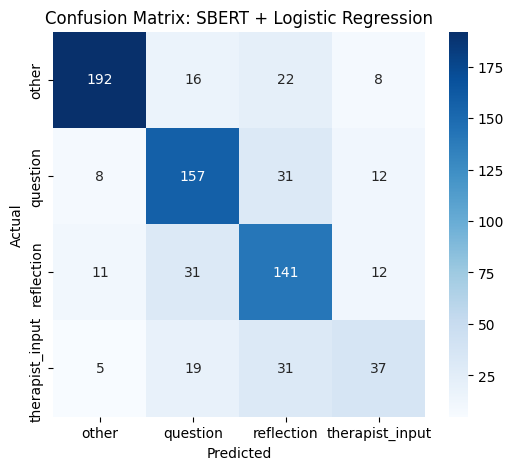

In [61]:
# Pick the best performing model from Part IV

cm = confusion_matrix(y_test, y_pred_sbert_lr)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: SBERT + Logistic Regression")
plt.show()

## 5.2. Classification report table

In [62]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_test,
    y_pred_sbert_lr,
    target_names=label_encoder.classes_,
    output_dict=True
)
report_df = pd.DataFrame(report).transpose()
report_df

,precision,recall,f1-score,support
other,0.888889,0.806723,0.845815,238.000000
question,0.704036,0.754808,0.728538,208.000000
reflection,0.626667,0.723077,0.671429,195.000000
therapist_input,0.536232,0.402174,0.459627,92.000000
accuracy,0.718963,0.718963,0.718963,0.718963
macro avg,0.688956,0.671695,0.676352,733.000000
weighted avg,0.722412,0.718963,0.717673,733.000000


In [63]:
# # Save evaluation results
# report_df.to_csv("classification_report_sbert_lr.csv")
# print("Saved evaluation report")

In [64]:
test_df = test_df.copy()
test_df["pred_label_id"] = best_pred
test_df["pred_label"] = label_encoder.inverse_transform(test_df["pred_label_id"])
test_df["true_label_id"] = test_df["label_id"]
test_df["true_label"] = test_df["label"]

errors_df = test_df[test_df["true_label"] != test_df["pred_label"]].copy()

print("Number of errors:", len(errors_df))
display(errors_df.head(10))


Number of errors: 206


,transcript_id,text,label,mi_quality,label_id,pred_label_id,pred_label,true_label_id,true_label
6837,98,"Well, I sure-sure would, um, tell the-the peop...",therapist_input,high,3,1,question,3,therapist_input
3525,55,That's great. And how do you want to get the i...,question,high,1,3,therapist_input,1,question
2434,38,"So, one thing that could make a big difference...",reflection,high,2,3,therapist_input,2,reflection
7839,115,"Well, there's-there's a reason that [crosstalk...",other,low,0,2,reflection,0,other
9328,133,And you can make lots of money and set yoursel...,question,high,1,2,reflection,1,question
3050,49,"So, one of the things that we started to touch...",reflection,high,2,1,question,2,reflection
2438,38,"Yeah. It-it sounds like, um, you know, money c...",question,high,1,2,reflection,1,question
4681,68,-of how much you can drink to have some of the...,reflection,high,2,3,therapist_input,2,reflection
9336,133,Yeah?,question,high,1,0,other,1,question
4388,64,So that might be something that we can look at...,therapist_input,high,3,1,question,3,therapist_input


In [65]:
test_df = test_df.copy()
test_df["pred_label_id"] = y_pred_sbert_lr
test_df["pred_label"] = label_encoder.inverse_transform(test_df["pred_label_id"])

errors_df = test_df[test_df["label"] != test_df["pred_label"]]

print("Number of errors:", len(errors_df))
errors_df.head(10)

Number of errors: 206


,transcript_id,text,label,mi_quality,label_id,pred_label_id,pred_label,true_label_id,true_label
6837,98,"Well, I sure-sure would, um, tell the-the peop...",therapist_input,high,3,1,question,3,therapist_input
3525,55,That's great. And how do you want to get the i...,question,high,1,3,therapist_input,1,question
2434,38,"So, one thing that could make a big difference...",reflection,high,2,3,therapist_input,2,reflection
7839,115,"Well, there's-there's a reason that [crosstalk...",other,low,0,2,reflection,0,other
9328,133,And you can make lots of money and set yoursel...,question,high,1,2,reflection,1,question
3050,49,"So, one of the things that we started to touch...",reflection,high,2,1,question,2,reflection
2438,38,"Yeah. It-it sounds like, um, you know, money c...",question,high,1,2,reflection,1,question
4681,68,-of how much you can drink to have some of the...,reflection,high,2,3,therapist_input,2,reflection
9336,133,Yeah?,question,high,1,0,other,1,question
4388,64,So that might be something that we can look at...,therapist_input,high,3,1,question,3,therapist_input


In [66]:
# Show error examples
for i, row in errors_df.sample(10, random_state=42).iterrows():
    print("TEXT:", row["text"])
    print("TRUE:", row["label"])
    print("PRED:", row["pred_label"])
    print("-"*60)

TEXT: Yeah. You seem a little surprised, I'm-I'm [crosstalk] wondering about, surprising face.
TRUE: reflection
PRED: question
------------------------------------------------------------
TEXT: So that might be something that we can look at but later if you're interested in is maybe what are some of those other parts of the gay scene, whose still party and party medley, but when meth is not a- is not a dominant-
TRUE: therapist_input
PRED: question
------------------------------------------------------------
TEXT: Oh, yeah? Yeah?
TRUE: other
PRED: question
------------------------------------------------------------
TEXT: All right. Well, some of the common side effects are nausea, vomiting, headache. There are some severe side effects like dermatomyositis, liver failure, lupus, rhabdomyolysis, hemorrhagic, cerebral infarction. If you have any of those, you should call your doctor.
TRUE: other
PRED: therapist_input
------------------------------------------------------------
TEXT: Yet.

In [67]:
# Class-wise error counts
errors_df["label"].value_counts()

,count
label,
therapist_input,55
reflection,54
question,51
other,46


# VI. Session-level Fidelity Analysis

Transcript utterance → Behaviour distribution → Subtype metrics → Session-level fidelity score

This section uses the **AnnoMI-full** subtype columns to move beyond plain behaviour classification.


## 6.1. Build utterance-level results table from the held-out test set

In [68]:
subtype_cols = [
    "question_exists",
    "question_subtype",
    "reflection_exists",
    "reflection_subtype",
    "therapist_input_subtype",
    "mi_quality"
]
existing_subtype_cols = [c for c in subtype_cols if c in test_df.columns]

results_df = test_df[["transcript_id", "text", "true_label", "pred_label"] + existing_subtype_cols].copy()

# helper: safe string normalization
def _norm_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip().lower()

# create boolean flags from full annotation columns
if "question_subtype" in results_df.columns:
    results_df["is_open_question"] = results_df["question_subtype"].apply(lambda x: "open" in _norm_str(x))
    results_df["is_closed_question"] = results_df["question_subtype"].apply(lambda x: "closed" in _norm_str(x))
elif "question_exists" in results_df.columns:
    results_df["is_open_question"] = False
    results_df["is_closed_question"] = results_df["question_exists"].astype(str).str.lower().isin(["1", "true", "yes"])

if "reflection_subtype" in results_df.columns:
    results_df["is_simple_reflection"] = results_df["reflection_subtype"].apply(lambda x: "simple" in _norm_str(x))
    results_df["is_complex_reflection"] = results_df["reflection_subtype"].apply(lambda x: "complex" in _norm_str(x))
elif "reflection_exists" in results_df.columns:
    results_df["is_simple_reflection"] = results_df["reflection_exists"].astype(str).str.lower().isin(["1", "true", "yes"])
    results_df["is_complex_reflection"] = False

if "therapist_input_subtype" in results_df.columns:
    results_df["is_advice"] = results_df["therapist_input_subtype"].apply(lambda x: "advice" in _norm_str(x))
else:
    results_df["is_advice"] = False

results_df.head()


,transcript_id,text,true_label,pred_label,mi_quality,is_advice
6150,93,Okay. Those are the big ones for you.,reflection,reflection,high,False
4862,71,"Well, have you got the forms with you?",question,question,high,False
4643,68,Okay.,other,other,high,False
6837,98,"Well, I sure-sure would, um, tell the-the peop...",therapist_input,question,high,False
5732,85,Mm-hmm.,other,other,high,False


## 6.2. Compute behaviour distribution per session

In [69]:
# predicted behaviour counts per transcript
session_pred_counts = results_df.groupby(["transcript_id", "pred_label"]).size().unstack(fill_value=0)

# predicted behaviour ratios
session_pred_ratios = session_pred_counts.div(session_pred_counts.sum(axis=1), axis=0)

# gold behaviour counts per transcript (useful for reference / discussion)
session_true_counts = results_df.groupby(["transcript_id", "true_label"]).size().unstack(fill_value=0)
session_true_ratios = session_true_counts.div(session_true_counts.sum(axis=1), axis=0)

print("Predicted session behaviour table shape:", session_pred_ratios.shape)
display(session_pred_ratios.head())

Predicted session behaviour table shape: (121, 4)


pred_label,other,question,reflection,therapist_input
transcript_id,,,,
0,0.000000,1.000000,0.00,0.000000
1,0.000000,0.500000,0.50,0.000000
2,0.166667,0.666667,0.00,0.166667
4,0.200000,0.400000,0.30,0.100000
5,0.166667,0.583333,0.25,0.000000


## 6.3. Create subtype-based fidelity metrics from AnnoMI-full

In [70]:
session_metrics = results_df.groupby("transcript_id").agg(
    total_utterances=("text", "size"),
    open_questions=("is_open_question", "sum"),
    closed_questions=("is_closed_question", "sum"),
    simple_reflections=("is_simple_reflection", "sum"),
    complex_reflections=("is_complex_reflection", "sum"),
    advice_count=("is_advice", "sum")
)

session_metrics["total_questions"] = session_metrics["open_questions"] + session_metrics["closed_questions"]
session_metrics["total_reflections"] = session_metrics["simple_reflections"] + session_metrics["complex_reflections"]

# avoid divide-by-zero with np.where
session_metrics["open_question_ratio"] = np.where(
    session_metrics["total_questions"] > 0,
    session_metrics["open_questions"] / session_metrics["total_questions"],
    0.0
)

session_metrics["complex_reflection_ratio"] = np.where(
    session_metrics["total_reflections"] > 0,
    session_metrics["complex_reflections"] / session_metrics["total_reflections"],
    0.0
)

session_metrics["reflection_to_question_ratio"] = np.where(
    session_metrics["total_questions"] > 0,
    session_metrics["total_reflections"] / session_metrics["total_questions"],
    np.nan
)

session_metrics["advice_ratio"] = np.where(
    session_metrics["total_utterances"] > 0,
    session_metrics["advice_count"] / session_metrics["total_utterances"],
    0.0
)

display(session_metrics.head())

KeyError: "Column(s) ['is_closed_question', 'is_complex_reflection', 'is_open_question', 'is_simple_reflection'] do not exist"

## 6.4. Fidelity scoring and interpretation

In [ ]:
def compute_fidelity(row):
    score = 0

    # higher is better
    if row["open_question_ratio"] >= 0.5:
        score += 1

    # higher is better
    if row["complex_reflection_ratio"] >= 0.4:
        score += 1

    # reflections should not be much lower than questions
    if pd.notna(row["reflection_to_question_ratio"]) and row["reflection_to_question_ratio"] >= 1.0:
        score += 1

    # lower advice use is better in MI-style interactions
    if row["advice_ratio"] <= 0.2:
        score += 1

    return score

session_metrics["fidelity_score"] = session_metrics.apply(compute_fidelity, axis=1)
session_metrics["high_fidelity"] = session_metrics["fidelity_score"] >= 3

display(session_metrics.sort_values("fidelity_score", ascending=False).head())


In [ ]:
# Optional: inspect relationship with transcript-level MI quality, if available
if "mi_quality" in results_df.columns:
    mi_by_session = (
        results_df.groupby("transcript_id")["mi_quality"]
        .agg(lambda s: s.dropna().mode().iloc[0] if not s.dropna().empty else np.nan)
        .rename("mi_quality_session")
    )

    session_metrics = session_metrics.join(mi_by_session, how="left")

    print("Fidelity score by MI quality:")
    display(session_metrics.groupby("mi_quality_session")["fidelity_score"].describe())
else:
    print("mi_quality column not available in test_df.")


In [ ]:
# Binary classification
session_metrics["high_fidelity"] = session_metrics["fidelity_score"] >= 1

## 6.5. Thesis-ready interpretation

At this point the pipeline does two things:

1. **Utterance-level behaviour classification** using the main therapist behaviour label.  
2. **Session-level fidelity analysis** using fine-grained subtype annotations from **AnnoMI-full**.

This is a stronger thesis framing than classification alone because it connects model outputs to clinically meaningful fidelity indicators such as:
- open question ratio
- complex reflection ratio
- reflection-to-question ratio
- advice ratio
